# **LAB 11**

## INTRODUZIONE AL MACHINE LEARNING
Il Machine Learning (ML) è un insieme di tecniche che permettono a un computer di imparare dai dati invece di essere programmato con regole esplicite. L’obiettivo è costruire un modello che riesca a fare previsioni anche su dati mai visti.

Si introducono ora una serie di concetti fondamentali del Machine Learning:
- Dataset: è l'insieme dei dati e solitamente è comosto da $(X,Y)$, dove $X$ è l'input (*feature*) e $Y$ è l'output (*target*, ovvero ciò che si vuole prevedere).
- Modello: è la funzione che il computer impara (in generale $y=f(x)$).
- Training: è la fase di apprendimento; il modello fa una previsione, confronta con il valore corretto, corregge i parametri e ripete molte volte questo processo.

Ci sono varie tipologie di Machine Learing: 
- **Supervised Learning**: viene fornito un input e la risposta corretta; dei problemi tipici che vengono affrontati con questo approccio sono problemi di regressione e classificazione.
- **Unsupervised Learingn**: viene fornito solamente l'input. Questo approccio viene utilizzato ad esempio per il clutering di clienti. 
- **Reinforcement Learing**: è basato sul metodo "tentativi ed errori". Un agente software impara a raggiungere un obiettivo compiendo azioni e ricevendo premi o penalità: il suo scopo è massimizzare le ricompense totali nel tempo.

#### DEEP LEARNING
Il Deep Learing è un sottoinsieme del Machine Learning e si basa su reti neurali organizzate su più livelli (da cui "profondo") che imitano il funzionamento del cervello umano. L'idea generale è che, al posto di utilizzare una funzione semplice, si usano molte trasformazioni una sopra all'altra. 

L'elemento base della rete neutrale è il neurone. Il neurone riceve numeri in ingresso, attribuisce un peso a ogni ingresso, somma tutto e decide cosa produrre. L'output del singolo neurone può essere così descritto: 

$$\text{output} = \text{attivazione}(\sum_i \omega_i x_i + b) $$

dove $x_i$ sono i dati di input, $\omega_i$ sono i pesi (quindi l'importanza di ogni dato), $b$ è il bias (piccolo aggiustamento) e attivazione è la funzione che determina il risultato finale. 

I neuroni lavorano insieme e sono raggruppati in dei *layer*: ogni layer estrae rappresentazioni sempre più utili. Inizialmente, i pesi sono assegnati casualmente e si ha una prima previsione. Si ha poi una funzione che calcola la perdita (*loss*), ovvero quanto il modello ha sbagliato, e di conseguenza vengono aggiornati i pesi. Questo processo viene ripetuto molte volte fino ad arrivare all'output finale. 

## **Esercizio 11.1**

In questo esercizio, si vuole costrutire una prima rete neurale che apprenda la relazione tra input e output a partire da dati generati artificialmente, nei quali è presente una dipendenza lineare tra le variabili ma con l’aggiunta di rumore. Si consideri il semplice caso: 
$$ f(x) = 2x+1 $$

Inizialmente, vengono generati dei dati di input casuali. Vengono creati due insiemi di punti x, uno per il training (1000 punti) e uno per la validazione (50 punti); entrambi sono estratti casualmente nell’intervallo $[−1,1]$: Nel validation set, questi dati vengono ordinati, in modo da poterli visualizzare meglio in un grafico. A questo punto vengono costruiti i valori “ideali” della funzione, cioè $y_{target}$, calcolati direttamente dalla retta perfetta senza errori: questo rappresenta la situazione teorica, ovvero quella che il modello deve imparare. 

In seguito, il modello viene reso realistico aggiungendo rumore gaussiano con deviazione standard $0.2$: dunque, al modello viene fornita una serie di informazioni "sporche" come avviene nel caso di dati reali. Le $y$ ottenute sono quindi: 
- $y_{train}$ = dati rumorosi usati per allenare il modello
- $y_{valid}$ = dati rumorosi usati per testare quanto il modello generalizza

In [174]:
# parametri target di f(x) = m*x + b
m = 2 # coeff agolare
b = 1 # intercetta

import numpy as np
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 1000)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b

sigma = 0.2 #rumore
y_train = np.random.normal(m * x_train + b, sigma)
y_valid = np.random.normal(m * x_valid + b, sigma)

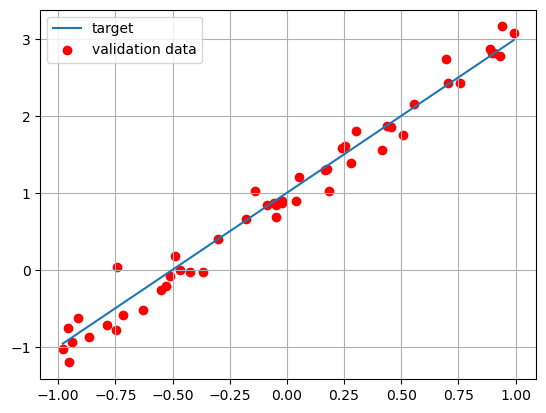

In [175]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

A questo punto viene costruito e preparato un modello di rete neurale per affrontare il problema di regressione lineare. Il modello utilizzato è estremamente essenziale: si tratta di una rete sequenziale composta da un singolo neurone, equivalente a una funzione lineare del tipo $y=\omega x+b$. Dopo la definizione della struttura della rete, il modello viene compilato specificando la funzione di ottimizzazione (gradient descent stocastico), la funzione di loss (errore quadratico medio) e la metrica utilizzata per monitorare le prestazioni durante l’addestramento.

Viene poi stampato un riassunto completo del modello.

In [176]:
# creazione del modello
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))

# complila il modello, scegliendo l'ottimizzatore, la funzione di loss e la metrica
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

In [177]:
# riassunto del modello
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Viene dunque eseguito l’addestramento (training) della rete neurale utilizzando il dataset generato in precedenza. Durante il training il modello confronta le proprie predizioni con i valori reali e aggiorna progressivamente i parametri interni (peso e bias) per ridurre l’errore. L’apprendimento viene monitorato anche su un insieme separato di dati di validazione, così da valutare la capacità del modello di generalizzare e non adattarsi esclusivamente ai dati di training.

I dati non vengono elaborati tutti insieme, ma vengono divisi in gruppi da 32 punti (`batch_size=32`). Invece, un’epoca corrisponde a un passaggio completo su tutto il dataset: quindi, in questo caso il modello vede tutti i dati 30 volte (`epochs=30`). Ad ogni epoca, il modello ricalcola predizioni, misura errore e migliora i parametri. Tramite il comando `shuffle=True`, i dati vengono mescolati casualmente prima di ogni epoca: questo evita che il modello impari dipendenze dovute all’ordine dei dati e rende il training generalmente più stabile.


Alla fine di ogni epoca il modello viene testato anche sul validation set. Questi dati non vengono usati per aggiornare i pesi, ma servono solo per controllare quanto il modello generalizza. Vengono quindi calcolate `loss` (errore calcolato sui dati di training) e `val_loss` (errore calcolato sui dati di validation) per confrontare training e validazione.

In [178]:
# allenamento del modello: 10 epoche in batch da 32
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True,
          validation_data=(x_valid, y_valid))

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6428 - mse: 2.6428 - val_loss: 2.0154 - val_mse: 2.0154
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5236 - mse: 1.5236 - val_loss: 1.2576 - val_mse: 1.2576
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9475 - mse: 0.9475 - val_loss: 0.8171 - val_mse: 0.8171
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6087 - mse: 0.6087 - val_loss: 0.5467 - val_mse: 0.5467
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4030 - mse: 0.4030 - val_loss: 0.3739 - val_mse: 0.3739
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2733 - mse: 0.2733 - val_loss: 0.2599 - val_mse: 0.2599
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1896 - mse: 0.1896 - val_loss: 0.1860 - val_mse: 0.1860
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1360 - mse: 0.1360 - val_loss: 0.1366 - val_mse: 0.1366
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1015 - mse: 

#### RISULTATI ALLENAMENTO

A questo punto vengono restituiti i parametri imparati dalla rete, ovvero il peso $\omega$ e il bias $b$. Dai risultati stampati qui sotto si nota che $\omega \approx 2$ e $b \approx 1$, comprendendo così che il modello ha imparato correttamente. 

In [179]:
# stampa del peso e del bias
model.get_weights()

[array([[1.9889762]], dtype=float32), array([1.0065298], dtype=float32)]

Viene poi calcolato l’errore del modello su dati di validazione.

In [180]:
# valutazione del modello
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# stampa delle performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0338 - mse: 0.0338

Test loss: 0.03384384512901306
Test accuracy: 0.03384384512901306


In seguito, si confronta il modello con la funzione perfetta senza rumore ($y_{target}$). Questo dice quanto il modello ha “capito la legge reale” e non solo il rumore.

In [181]:
# valutazione del modello con la curva esatta
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# stampa delle performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9.0946e-05 - mse: 9.0946e-05

Test loss: 9.094588313018903e-05
Test accuracy: 9.094588313018903e-05


Di seguito vengono plottati gli errori del training e della validation in funzione delle epoche, mostrando appunto come il modello apprende nel tempo. Osservando questo grafico si può concludere che, dato che entrambi gli errori diminuiscono, il modello ha imparato correttamente. Nel caso in cui si verificasse che il training scende e il validation sale, ciò sarebbe sintomo di overfitting.

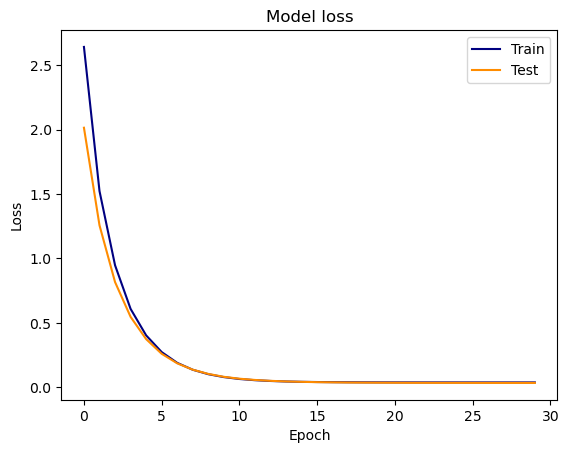

In [182]:
plt.plot(history.history['loss'], color = 'navy')
plt.plot(history.history['val_loss'], color = 'darkorange')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

Infine, si vuole far lavorare il modello su dei dati nuovi. Dunque, vengono generati nuovi punti casuali $x$ e si utilizza il modello per predirre le $y$. I punti generati dal modello in generale sono compatibili con la retta $y=2x+1$: possiamo concludere che il modello ha imparato bene. 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


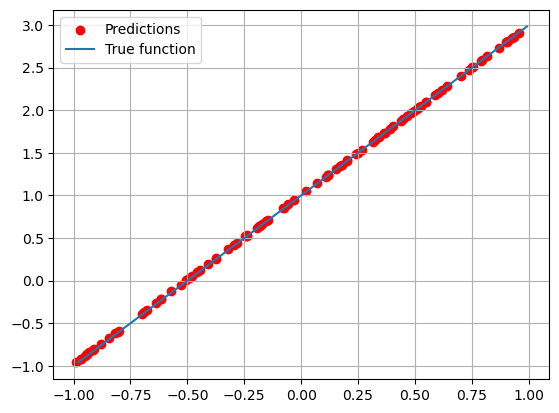

In [183]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r', label='Predictions')
plt.plot(x_valid, y_target, label='True function')
plt.grid(True)
plt.legend()
plt.show()

#### OSSERVAZIONI FINALI
Come già accennano, quando si costruisce una NN, deve essere settata una serie di parametri, tra cui il numero delle epoche ($N_{\mathrm{epochs}}$), il numero dei dati di training $N_{\mathrm{train}}$ e il rumore $\sigma$.  
Prima di settare i parametri riportati nella spiegazione al paragrafo precedente, sono state eseguite delle prove per cercare di migliorare le prestazioni del modello. Di seguito sono riportate le conclusioni a cui si è giunti: 
- Il numero di epoche è stato settato a 30; tuttavia, come si può osservare dal grafico della loss, l'errore rimane costante da circa 15 epoche in poi.
- Il fit migliora se si aumentano i punti di training da 500 a 1000.
- Il risultato peggiora se viene aumentato il rumore.

## **Esercizio 11.2**

Si vuole ora estendere il modello dell'esercizio precedente per ottenere un fit del seguente polinomio del terzo ordine: 

$$ f(x)=4-3x-2x^2+3x^3 \qquad x \in [-1,1]$$


L’obiettivo non è solo ottenere un buon fit, ma capire come cambiano le prestazioni del modello al variare della sua complessità (numero di layer, neuroni, numero di epoche ecc) e verificare la capacità di generalizzazione sia dentro che fuori dall’intervallo di training.

Innanzitutto, si genera il set di dati come avvenuto nell'esercizio 11.1, aggiungendo del rumore gaussiano per simulare dati realistici. Prima di costruire la rete, vengono visualizzati i dati.   

In [1]:
# parametri target di f(x) = a + bx + cx2 + dx3
a = 4
b = -3
c = -2
d = 3


import numpy as np
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 2500)
x_valid = np.random.uniform(-1, 1, 100)
x_valid.sort()
y_target = a + b*x_valid + c*(x_valid**2) + d*(x_valid**3)

x_test_out = np.linspace(-2, 2, 100)
y_test_out = a + b*x_test_out + c*(x_test_out**2) + d*(x_test_out**3)

sigma = 0.1
y_train = np.random.normal(a + b*x_train + c*(x_train**2) + d*(x_train**3), sigma)
y_valid = np.random.normal(a + b*x_valid + c*(x_valid**2) + d*(x_valid**3), sigma)

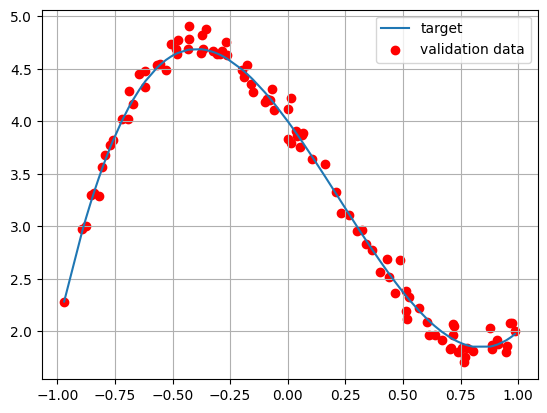

In [2]:
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

A questo punto viene modificata la struttura della rete neurale: lo scopo è quello di renderla più complessa e più adatta al fit di un polinomio del terzo ordine. 

Per questa rete sono stati scelti: 
- **2 hidden layers**: si tratta di livelli intermedi della rete neurale tra input layer e output layer; permettono alla rete di costruire una composizione di funzioni non lineari, aumentando la capacità di rappresentare forme curve più complesse rispetto a un singolo layer.
- **30 neuroni per layer**: è un valore intermedio che garantisce buona capacità di approssimazione senza complicare troppo il modello. Infatti, con pochi neuroni la rete non riesce a rappresentare bene la non linearità, correndo così il rischio di underfitting; viceversa, con troppi neuroni la rete diventa troppo flessibile e rischia di imparare anche il rumore (overfitting).
- **Funzione di attivazione ReLu** (*Rectified Linear Unit*): se l'input è negativo allora l'output è nullo, mentre se l'input è positivo allora l'output è uguale all'input, ovvero $g(x) = \max{(0,x)}$
- **Ottimizzatore Adam**: è una versione migliorata del gradient descent.
- **Funzione di loss MSE** (*Median Squared Error*): misura la distanza quadratica tra predizione e valore reale.

Il modello viene poi allenato con 30 epoche.

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(30, input_shape=(1,), activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

/opt/anaconda3/envs/lab12/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,021 (3.99 KB)

 Trainable params: 1,021 (3.99 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    x_train,
    y_train,
    epochs=60,
    validation_split=0.2,
    verbose=1
)

Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.7366 - mae: 2.8929 - val_loss: 7.2612 - val_mae: 2.3727
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.8969 - mae: 1.6397 - val_loss: 1.6535 - val_mae: 1.1503
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0651 - mae: 0.8659 - val_loss: 0.8869 - val_mae: 0.7697
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6408 - mae: 0.6296 - val_loss: 0.5466 - val_mae: 0.5592
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3882 - mae: 0.4575 - val_loss: 0.3300 - val_mae: 0.4078
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2345 - mae: 0.3313 - val_loss: 0.2018 - val_mae: 0.3206
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1447 - mae: 0.2558 - val_loss: 0.1224 - val_mae: 0.2399
Epoch 8/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0909 - mae: 0.2006 - val_loss: 0.0771 - val_mae: 0.1916
Epoch 9/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0611 - mae: 

In [25]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0126 - mae: 0.0894 

Test loss: 0.012584767304360867
Test accuracy: 0.08941186219453812


In [6]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1361e-04 - mae: 0.0196 

Test loss: 0.0007136114872992039
Test accuracy: 0.019640272483229637


Dopo l’addestramento del modello, è utile osservare l’andamento della funzione di loss durante le epoche per verificare se la rete sta imparando correttamente. Dal grafico si osserva che la loss diminuisce progressivamente nelle prime epoche, indicando che il modello riesce a ridurre l’errore tra le predizioni e i valori reali della funzione. Successivamente la curva tende a stabilizzarsi, segno che il processo di ottimizzazione sta convergendo verso una soluzione stabile. L’assenza di oscillazioni significative suggerisce che il learning rate scelto è adeguato (valore di default di Adam pari a 0.001) e che il training risulta sufficientemente stabile.

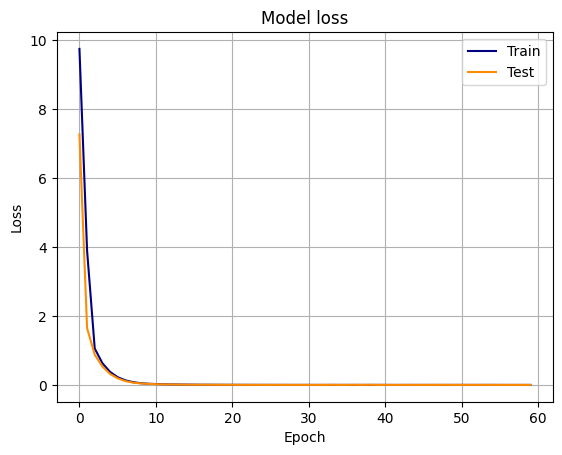

In [7]:
import matplotlib.pyplot as plt

# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], color = 'navy')
plt.plot(history.history['val_loss'], color = 'darkorange')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid(True)
plt.show()

Per verificare la capacità di generalizzazione del modello, vengono generati nuovi punti nell’intervallo $[−1,1]$, cioè nello stesso dominio utilizzato durante il training. Il confronto tra la funzione reale e le predizioni della rete mostra che il modello riesce a seguire correttamente l’andamento del polinomio; infatti, i punti predetti risultano generalmente sovrapposti alla funzione teorica, indicando che la rete non ha semplicemente memorizzato i dati di training ma ha effettivamente appreso la relazione tra input e output. Questo comportamento mostra una buona capacità di interpolazione, cioè la capacità di stimare correttamente valori compresi all’interno del dominio osservato durante l’addestramento.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


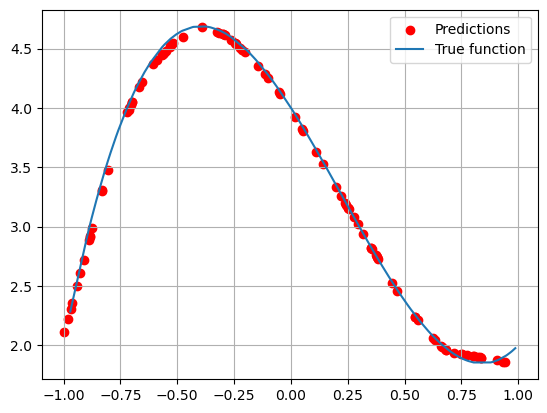

In [32]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r', label='Predictions')
plt.plot(x_valid, y_target, label='True function')
plt.grid(True)
plt.legend()
plt.show()

Successivamente il modello viene testato su un intervallo più ampio, estendendo i valori di input fino a $[−2,2]$. Le linee verticali tratteggiate evidenziano il dominio effettivamente utilizzato durante il training.

All’interno della regione compresa tra −1 e 1, il comportamento della rete rimane accurato e coerente con la funzione teorica. Al di fuori di questo intervallo, invece, si osserva una progressiva perdita di accuratezza. Questo risultato era atteso: la rete neurale è stata addestrata esclusivamente su valori interni all’intervallo iniziale e quindi, per punti esterni, deve effettuare una extrapolazione. A differenza dell’interpolazione, l’extrapolazione è generalmente più difficile perché il modello non possiede informazioni dirette sul comportamento della funzione in quelle regioni. Di conseguenza, il modello perde capacità predittiva.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


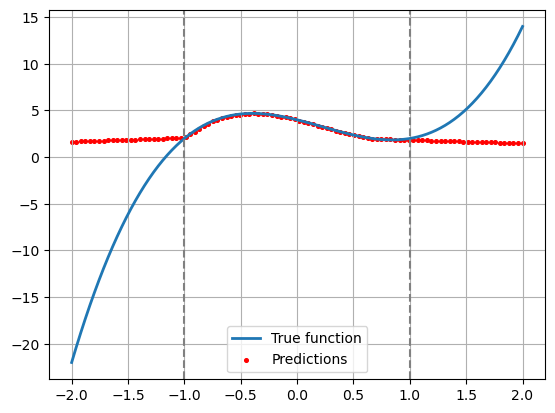

In [33]:
y_pred_out = model.predict(x_test_out)

plt.plot(x_test_out, y_test_out, lw=2, label="True function")
plt.scatter(x_test_out, y_pred_out, lw=1, s=7, label= "Predictions", color='red')
plt.axvline(x=-1, linestyle='--', color='grey')
plt.axvline(x=1, linestyle='--', color='grey')

plt.legend()
plt.grid(True)

plt.show()

## **Esercizio 11.3**

In questo esercizio si vuole estendere il modello precedente al caso di una funzione con due variabili di input: 

$$ f(x,y) = \sin(x^2+y^2) \qquad x \in [-\frac{3}{2},\frac{3}{2}], y \in [-\frac{3}{2},\frac{3}{2}] $$

A differenza dell’esercizio precedente, il modello deve apprendere una superficie nello spazio tridimensionale $(x,y,f(x,y))$. L’obiettivo è verificare la capacità della rete di rappresentare relazioni non lineari tra più variabili e valutarne la capacità di generalizzazione.

Come avvenuto negli esercizi precedenti, viene inizialmente generato e rappresentato il dataset. 

In [2]:
import numpy as np

def f(x,y):
    return np.sin(x**2+y**2)

N_train = 5000
N_valid = 1000
x_train = np.random.uniform(-1.5, 1.5, N_train)
x_valid = np.random.uniform(-1.5, 1.5, N_valid)

y_train = np.random.uniform(-1.5, 1.5, N_train)
y_valid = np.random.uniform(-1.5, 1.5, N_valid)

z_target = f(x_valid, y_valid)

sigma = 0.1
z_train = np.random.normal(f(x_train,y_train), sigma)
z_valid = np.random.normal(f(x_valid,y_valid), sigma)


input_train = np.column_stack((x_train,y_train))
input_valid = np.column_stack((x_valid,y_valid))

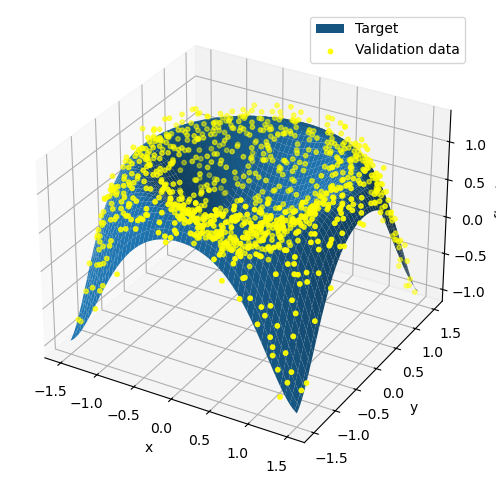

In [3]:
import matplotlib.pyplot as plt

grid = np.linspace(-1.5,1.5,100)
X,Y = np.meshgrid(grid,grid)

Z = f(X,Y)
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(projection='3d')


ax.plot_surface(X, Y, Z, label = 'Target')
ax.scatter(x_valid, y_valid, z_valid.flatten(), color='yellow', s=10, label='Validation data')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")

plt.legend()
plt.show()

Successivamente è stato costruito il modello. Poiché il problema presenta due variabili di ingresso, il layer iniziale riceve in input una coppia di valori (x,y), motivo per cui viene impostato `input_shape=(2,)`.

La rete è composta da tre hidden layers con 40 neuroni ciascuno. L’utilizzo di più layer rispetto all’esercizio precedente è motivato dalla maggiore complessità della funzione da apprendere: il modello deve infatti rappresentare una superficie bidimensionale non lineare con andamento oscillatorio.
Come funzione di attivazione è stata scelta ReLU: questa funzione introduce non linearità nel modello e permette alla rete di costruire approssimazioni di funzioni complesse tramite combinazioni successive di trasformazioni lineari. Per l’ottimizzazione è stato utilizzato l’algoritmo Adam, scelto per la sua stabilità e velocità di convergenza durante il training. Come funzione di costo è stata utilizzata la Mean Squared Error (MSE), particolarmente adatta nei problemi di regressione perché penalizza maggiormente errori di grande entità.



In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential()

model.add(Dense(40, activation='relu',input_shape=(2,)))
model.add(Dense(40, activation='relu',))
model.add(Dense(40, activation='relu',))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 40)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 40)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,441 (13.44 KB)

 Trainable params: 3,441 (13.44 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    input_train,
    z_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1876 - mae: 0.3258 - val_loss: 0.1386 - val_mae: 0.2939
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1356 - mae: 0.2769 - val_loss: 0.1129 - val_mae: 0.2527
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0990 - mae: 0.2301 - val_loss: 0.0681 - val_mae: 0.1894
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0604 - mae: 0.1755 - val_loss: 0.0392 - val_mae: 0.1435
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0335 - mae: 0.1338 - val_loss: 0.0230 - val_mae: 0.1138
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - loss: 0.0206 - mae: 0.1078 - val_loss: 0.0154 - val_mae: 0.0944
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - loss: 0.0157 - mae: 0.0956 - val_loss: 0.0139 - val_mae: 0.0918
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 0.0135 - mae: 0.0904 - val_loss: 0.0120 - val_mae: 0.0859
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/s

In [27]:
# valutazione del modello
score = model.evaluate(input_valid, z_valid, batch_size=30)

# stampa delle performances
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - loss: 0.0114 - mae: 0.0849

Test loss: 0.011354975402355194
Test accuracy: 0.08486693352460861


Il grafico riportato di seguito mostra l’evoluzione della funzione di loss durante le epoche sia sui dati di training sia sui dati di validazione: si osserva una diminuzione progressiva di entrambe le curve, segno che il modello riesce ad apprendere la relazione tra le variabili di ingresso e il valore della funzione target. La vicinanza tra training loss e validation loss suggerisce che il modello mantiene una buona capacità di generalizzazione e non mostra evidenti fenomeni di overfitting.

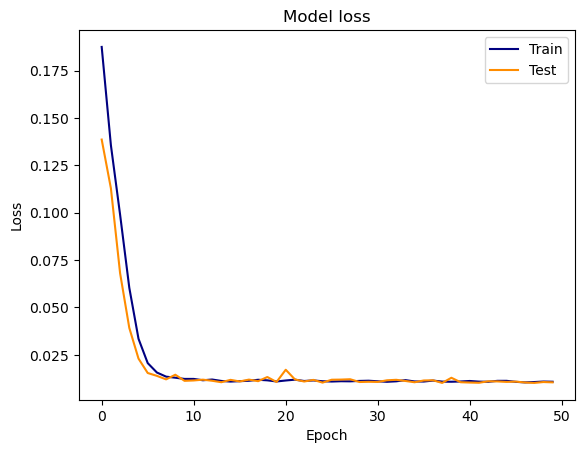

In [28]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], color = 'navy')
plt.plot(history.history['val_loss'], color = 'darkorange')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

Per valutare qualitativamente il comportamento della rete, le predizioni sono state confrontate con la superficie teorica della funzione. I punti predetti dal modello seguono complessivamente l’andamento della superficie reale, mostrando che la rete è riuscita ad apprendere la dipendenza non lineare tra le variabili x e y.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


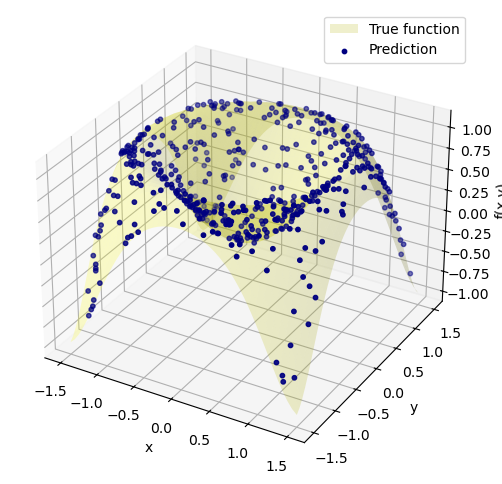

In [29]:
N_predicted = 500

x_predicted = np.random.uniform(-1.5, 1.5, N_predicted)
y_predicted = np.random.uniform(-1.5, 1.5, N_predicted)

input_pred = np.column_stack((x_predicted, y_predicted))
z_predicted = model.predict(input_pred)

grid = np.linspace(-1.5, 1.5, 50)
X, Y = np.meshgrid(grid, grid)
Z_true = f(X, Y)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(projection='3d')

ax.plot_surface(X, Y, Z_true, alpha=0.2, color='yellow', label = 'True function')
ax.scatter(x_predicted, y_predicted, z_predicted.flatten(), color='navy', s=10, label='Prediction')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
plt.legend()

plt.show()